In [1]:
import os
from tqdm.auto import tqdm
import xml.etree.ElementTree as ET

import tensorflow as tf
from tensorflow import keras

import keras_cv
from keras_cv import bounding_box
from keras_cv import visualization

import numpy as np

2025-02-18 12:57:34.134685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-18 12:57:34.144573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739901454.156651  509910 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739901454.160320  509910 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-18 12:57:34.172426: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [10]:

FINE_TUNE = False

SPLIT_RATIO = 0.2
BATCH_SIZE = 4

LEARNING_RATE = 0.001
FINE_TUNE_LR = 0.001 

EPOCH = 100 
INITIAL_EPOCHS = 7

GLOBAL_CLIPNORM = 10.0
IMAGE_SIZE = 640
MAX_BOXES=8


In [3]:
# Define class mappings
class_ids = ["corner"]
class_mapping = dict(zip(range(len(class_ids)), class_ids))

# Path to images and annotations
path_images = "data/corners/processed/diamond_captures_630/img/"
path_anno = "data/corners/processed/diamond_captures_630/anno_keras/"

txt_files = sorted(
    [
        os.path.join(path_anno, file) 
        for file in os.listdir(path_anno) 
        if file.endswith(".txt") and file != "labels.txt"
    ]
)

# Get all image files (.jpg) and sort them
jpg_files = sorted(
    [os.path.join(path_images, file) for file in os.listdir(path_images) if file.endswith(".jpg")]
)

In [4]:
def parse_annotation(txt_file):
    base_name = os.path.splitext(os.path.basename(txt_file))[0]
    image_path = os.path.join(path_images, base_name + ".jpg")

    boxes = []
    class_ids_list = []

    with open(txt_file, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            cls_id, xmin, ymin, xmax, ymax = map(float, parts)
            cls_id = int(cls_id) 
            
            # Append bounding box
            boxes.append([xmin, ymin, xmax, ymax])
            class_ids_list.append(cls_id)

    return image_path, boxes, class_ids_list

In [5]:
# Placeholders for dense arrays
image_paths = []
bbox = []
classes = []

for txt_file in tqdm(txt_files, desc="Parsing annotations"):
    image_path, boxes, class_ids = parse_annotation(txt_file)
    image_paths.append(image_path)
    bbox.append(boxes)
    classes.append(class_ids)
    
bbox = tf.ragged.constant(bbox)
classes = tf.ragged.constant(classes)
image_paths = tf.ragged.constant(image_paths)
data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))

Parsing annotations:   0%|          | 0/275 [00:00<?, ?it/s]

I0000 00:00:1739901468.371448  509910 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9386 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    # image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))  # Resize to fixed size
    return image


def load_dataset(image_path, classes, bbox):
    # Read Image
    image = load_image(image_path)
    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox,
    }
    return {"images": tf.cast(image, tf.float32), "bounding_boxes": bounding_boxes}

In [7]:
num_val = int(len(txt_files) * SPLIT_RATIO)

data = tf.data.Dataset.from_tensor_slices((image_paths, classes, bbox))
val_data = data.take(num_val)
train_data = data.skip(num_val)

augmenter = keras.Sequential(
    layers=[
        keras_cv.layers.RandomFlip(mode="horizontal", bounding_box_format="xyxy"),
        keras_cv.layers.RandomShear(
            x_factor=0.3, y_factor=0.3, bounding_box_format="xyxy"
        ),
        keras_cv.layers.JitteredResize(
            target_size=(IMAGE_SIZE, IMAGE_SIZE), scale_factor=(1, 1), bounding_box_format="xyxy"
        ),
    ]
)

train_ds = train_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BATCH_SIZE * 4)
train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
train_ds = train_ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
# train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


resizing = keras_cv.layers.JitteredResize(
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    scale_factor=(1, 1),
    bounding_box_format="xyxy",
)

val_ds = val_data.map(load_dataset, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(BATCH_SIZE * 4)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.map(resizing, num_parallel_calls=tf.data.AUTOTUNE)

# val_ds = val_ds.repeat()
# val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

def dict_to_tuple(inputs):
    return inputs["images"], bounding_box.to_dense(inputs["bounding_boxes"], max_boxes=MAX_BOXES)


train_ds = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [8]:
class SaveModelCallback(keras.callbacks.Callback):
    def __init__(self, data, save_path):
        super().__init__()
        self.data = data
        self.save_path = save_path

        if not os.path.exists(self.save_path):
            os.makedirs(self.save_path, exist_ok=True)

    def on_epoch_end(self, epoch, logs):

        path = f"{self.save_path}/corners_e{epoch}.keras"
        self.model.save(path)  # Save the model when mAP improves
        return logs

class TensorboardCallback(tf.keras.callbacks.Callback):
    def __init__(self, log_dir="train/logs/corner/"):
        super(TensorboardCallback, self).__init__()
        # Create a timestamped log directory
        self.log_dir = os.path.join(log_dir, "fit")
        
        # Create a TensorBoard writer
        self.writer = tf.summary.create_file_writer(self.log_dir)

    def on_train_begin(self, logs=None):
        print(f"TensorBoard logging started at: {self.log_dir}")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        with self.writer.as_default():
            for key, value in logs.items():
                tf.summary.scalar(key, value, step=epoch)  # Log each metric
            self.writer.flush()  # Ensure logs are written

In [9]:
tf.compat.v1.enable_eager_execution()

if FINE_TUNE:
    backbone = keras_cv.models.YOLOV8Backbone.from_preset(
        "yolo_v8_s_backbone_coco"
    )
    
    yolo = keras_cv.models.YOLOV8Detector(
        num_classes=len(class_mapping),
        bounding_box_format="xyxy",
        backbone=backbone,
        fpn_depth=1,
    )
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=GLOBAL_CLIPNORM,
    )
    
    # Train with the backbone frozen
    backbone.trainable = False
    yolo.compile(
        optimizer=optimizer, 
        classification_loss="binary_crossentropy", 
        box_loss="ciou"
    )
    yolo.fit(
        train_ds,
        validation_data=[val_ds],
        epochs=INITIAL_EPOCHS,
        callbacks=[SaveModelCallback(val_ds, "models/")]
    )
    
    # Unfreeze backbone for fine-tuning
    backbone.trainable = True
    fine_tune_optimizer = tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR, 
        global_clipnorm=GLOBAL_CLIPNORM
    )
    yolo.compile(
        optimizer=fine_tune_optimizer, 
        classification_loss="binary_crossentropy", 
        box_loss="ciou"
    )
    yolo.fit(
        train_ds,
        validation_data=[val_ds],
        epochs=EPOCH,
        callbacks=[SaveModelCallback(val_ds, "models/")]
    )
else:    
    backbone = keras_cv.models.YOLOV8Backbone.from_preset(
        "yolo_v8_xs_backbone"
    )
    
    yolo = keras_cv.models.YOLOV8Detector(
        num_classes=len(class_mapping),
        bounding_box_format="xyxy",
        backbone=backbone,
        fpn_depth=1,
    )
    
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        global_clipnorm=GLOBAL_CLIPNORM,
    )
    
    yolo.compile(
        optimizer=optimizer, classification_loss="binary_crossentropy", box_loss="ciou"
    )
    
    print(train_ds)
    
    yolo.fit(
        train_ds,
        validation_data=[val_ds],
        epochs=EPOCH,
        callbacks=[SaveModelCallback(val_ds, "train/models/corner/"), TensorboardCallback()],
    )

<_PrefetchDataset element_spec=(TensorSpec(shape=(4, 630, 630, 3), dtype=tf.float32, name=None), {'classes': TensorSpec(shape=(4, 8), dtype=tf.float32, name=None), 'boxes': TensorSpec(shape=(4, 8, 4), dtype=tf.float32, name=None)})>
TensorBoard logging started at: train/logs/fit
Epoch 1/100


/home/andrew/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(4, 630, 630, 3))
  warnings.warn(msg)


ValueError: Exception encountered when calling Concatenate.call().

[1mDimension 1 in both shapes must be equal, but are 80 and 79. Shapes are [4,80,80] and [4,79,79]. for '{{node yolov8_detector_1/concat_2}} = ConcatV2[N=2, T=DT_FLOAT, Tidx=DT_INT32](yolov8_detector_1/Repeat_3/Reshape_1, yolov8_detector_1/functional_1/stack2_c2f_output_1/IdentityN, yolov8_detector_1/concat_2/axis)' with input shapes: [4,80,80,128], [4,79,79,64], [] and with computed input tensors: input[2] = <-1>.[0m

Arguments received by Concatenate.call():
  • xs=['tf.Tensor(shape=(4, 80, 80, 128), dtype=float32)', 'tf.Tensor(shape=(4, 79, 79, 64), dtype=float32)']

(4, 640, 640, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
tf.Tensor(
[[[[0.75686276 0.88235295 0.83137256]
   [0.7529412  0.8784314  0.827451  ]
   [0.7529412  0.8784314  0.827451  ]
   ...
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]]

  [[0.75686276 0.88235295 0.83137256]
   [0.7529412  0.8784314  0.827451  ]
   [0.7529412  0.8784314  0.827451  ]
   ...
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]]

  [[0.7529412  0.8784314  0.827451  ]
   [0.7529412  0.8784314  0.827451  ]
   [0.75686276 0.88235295 0.83137256]
   ...
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]
   [0.07843138 0.07843138 0.07843138]]

  ...

  [[0.627451   0.50980395 0.23529412]
   [0.6156863  0.5019608  0.22745098]
   [0.59607846 0.5058824  0.23137255]
   ...
   [0.29803923 0.29411766 0.3137255 ]
   [0.28627452 0.28235295 0.3019608 ]
   [0.25882354 0.2549

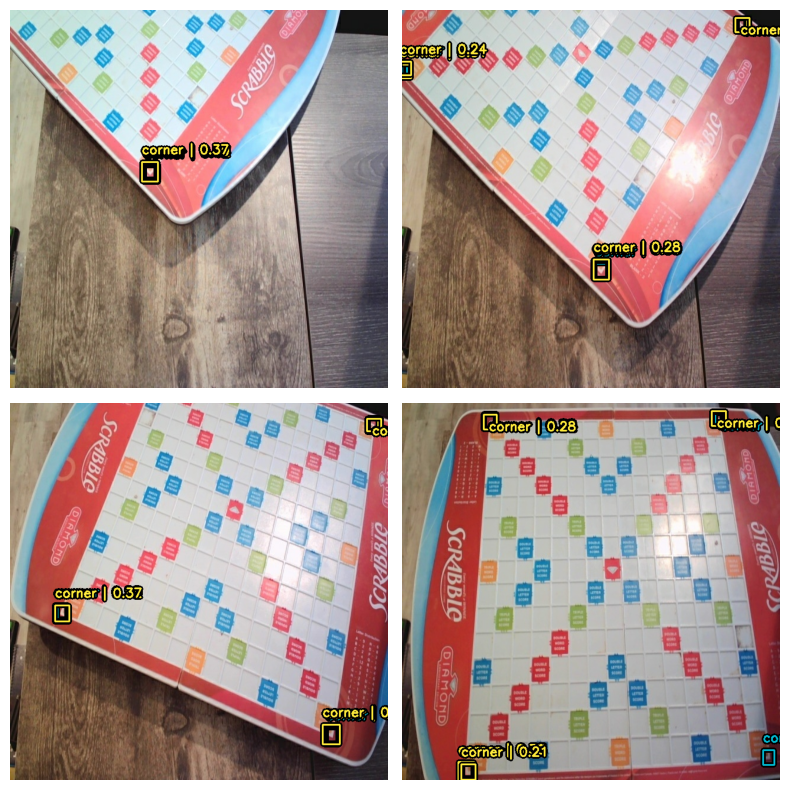

In [10]:
def visualize_detectione(model, dataset, bounding_box_format):
    batch = next(iter(dataset.take(1)))  # Get one batch
    images = batch[0]
    y_true = batch[1]

    # Ensure images are tensors
    images = tf.convert_to_tensor(images)
    print(images.shape)

    # Predict bounding boxes
    y_pred = model.predict(images)

    
    # Convert y_pred bounding boxes to the required format
    y_pred = keras_cv.bounding_box.convert_format(
        y_pred,
        source="xyxy",  # Adjust if necessary
        target=bounding_box_format,  # Ensure it matches expected format
        images=images,
    )
    print(images)
    # Plot bounding box predictions
    visualization.plot_bounding_box_gallery(
        images.numpy()*255,  # Convert to NumPy for visualization
        value_range=(0,255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        scale=4,
        rows=2,
        cols=2,
        show=True,
        font_scale=0.7,
        class_mapping=class_mapping,
    )

# Call the function
visualize_detections(yolo, dataset=val_ds, bounding_box_format="xyxy")


{'classes': <tf.Tensor: shape=(4, 8), dtype=float32, numpy=
array([[ 0.,  0.,  0., -1., -1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0., -1., -1., -1., -1.],
       [ 0., -1., -1., -1., -1., -1., -1., -1.],
       [ 0.,  0., -1., -1., -1., -1., -1., -1.]], dtype=float32)>, 'boxes': <tf.Tensor: shape=(4, 8, 4), dtype=float32, numpy=
array([[[340.352   ,  81.636536, 361.688   ,  98.01475 ],
        [ 76.15679 , 248.99397 , 123.940796, 287.08063 ],
        [452.54715 , 544.3385  , 521.11035 , 591.76746 ],
        [ -1.      ,  -1.      ,  -1.      ,  -1.      ],
        [ -1.      ,  -1.      ,  -1.      ,  -1.      ],
        [ -1.      ,  -1.      ,  -1.      ,  -1.      ],
        [ -1.      ,  -1.      ,  -1.      ,  -1.      ],
        [ -1.      ,  -1.      ,  -1.      ,  -1.      ]],

       [[134.20337 , 247.60353 , 154.09467 , 269.9913  ],
        [307.54    , 121.839355, 327.3262  , 143.20393 ],
        [447.73605 , 344.76477 , 465.15265 , 371.6067  ],
        [260.56253 , 499.4

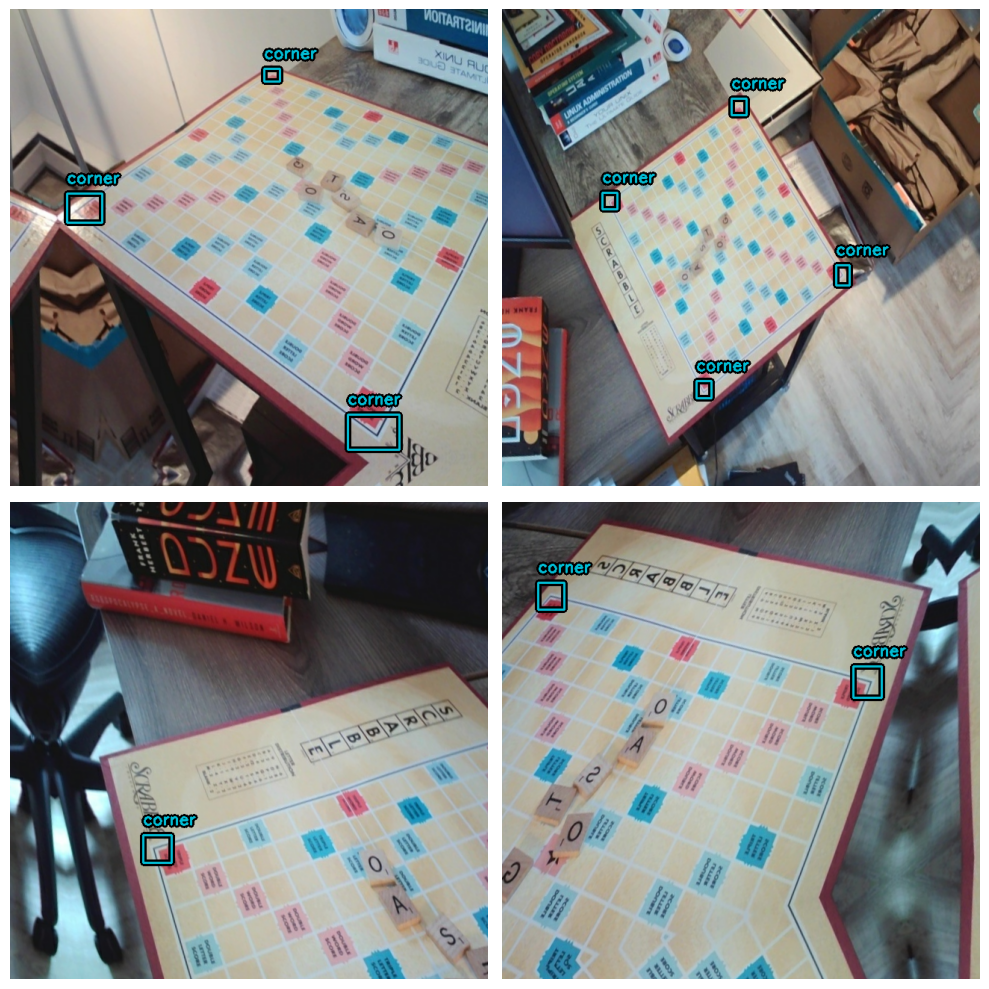

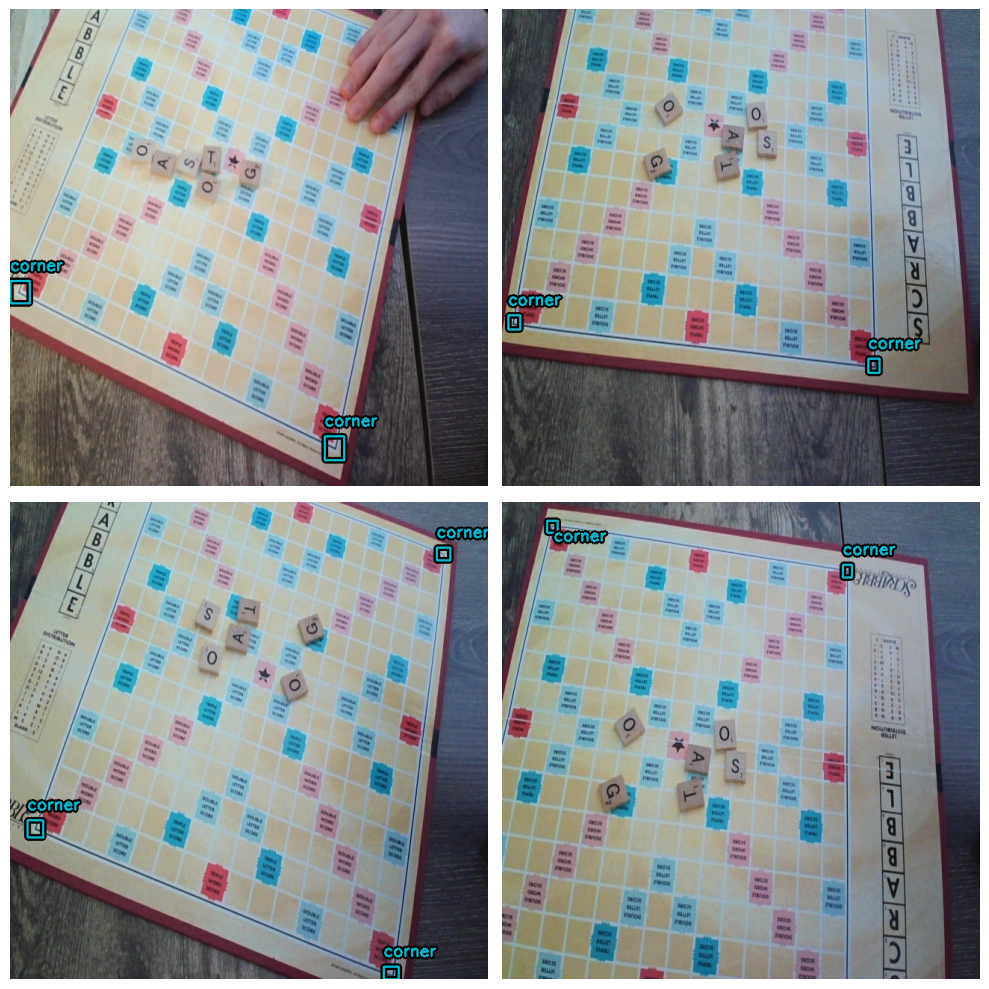

In [67]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs[0], inputs[1]
    print(bounding_boxes)
    visualization.plot_bounding_box_gallery(
        images*255,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale=5,
        font_scale=0.7,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
    )


visualize_dataset(
    train_ds, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=2
)

visualize_dataset(
    val_ds, bounding_box_format="xyxy", value_range=(0, 255), rows=2, cols=2
)